In [ ]:
# Install hypertools (run this first on Colab)
%pip install -q "hypertools[interactive]"

# Fitted models and pipelines: `return_model=True`, `.transform`, `pipeline=`, `apply_model` and `Pipeline`

Every hypertools dispatcher -- `manip`, `normalize`, `reduce`, `align`, `cluster`, `predict`, `impute` -- accepts `return_model=True` and hands back the fitted model alongside its result. A fitted model re-applies its learned parameters to new data, either through its own `.transform` or by passing it back to the dispatcher as `model=`. `hyp.plot(..., return_model=True)` returns a bundle whose `pipeline` replays the whole analysis on new data via `pipeline=`. `hyp.apply_model` runs any scikit-learn-style model in an explicit mode, and `hyp.Pipeline` chains specs by hand.

Throughout, the three `weights_sample` subjects are split in time: the first 200 timepoints fit each model and the last 100 are the held-out data it is re-applied to.

## Import packages and split the data

In [1]:
import numpy as np
import pandas as pd

import hypertools as hyp

%matplotlib inline
subjects = hyp.load('weights_sample')
train = [s[:200] for s in subjects]
test = [s[200:] for s in subjects]
[s.shape for s in train], [s.shape for s in test]

([(200, 100), (200, 100), (200, 100)], [(100, 100), (100, 100), (100, 100)])

## `manip`

`hyp.manip` returns DataFrames (index and columns preserved). A fitted manipulator re-applies through `.transform` or as `model=`; the two calls below give the same answer.

In [2]:
smoothed, smoother = hyp.manip(train, model='Smooth', kernel_width=11, return_model=True)
again = hyp.manip(test, model=smoother)
print(smoother, [a.shape for a in smoothed], '->', [a.shape for a in again])
print('same as smoother.transform(test):',
      all(np.allclose(a, b) for a, b in zip(again, smoother.transform(test))))

Smooth() [(200, 100), (200, 100), (200, 100)] -> [(100, 100), (100, 100), (100, 100)]
same as smoother.transform(test): True


## `normalize`

`hyp.normalize` z-scores (by default `'across'` datasets: one set of column statistics over the stacked rows) and returns numpy arrays. Re-applying the fitted scaler to held-out data uses the training mean and standard deviation, which is why the held-out columns do not come out at exactly zero mean.

In [3]:
normalized, scaler = hyp.normalize(train, return_model=True)
held_out = hyp.normalize(test, model=scaler)
print(scaler)
print('training column means:', np.round(np.vstack(normalized).mean(), 3),
      '  held-out, with the training statistics:', np.round(np.vstack(held_out).mean(), 3))

Normalizer()
training column means: 0.0   held-out, with the training statistics: -0.006


## `reduce`

The reducer is fit once on the stacked training rows, so every dataset lands in one shared space; `model=` projects new rows into that same space without refitting.

In [4]:
reduced, pca = hyp.reduce(train, reduce='PCA', ndims=3, return_model=True)
projected = hyp.reduce(test, model=pca)
print(pca, [a.shape for a in reduced], '->', [a.shape for a in projected])

Reducer(model=PCA(n_components=3)) [(200, 3), (200, 3), (200, 3)] -> [(100, 3), (100, 3), (100, 3)]


## `align`

`hyp.align` learns one transformation per dataset into a shared space (hyperalignment here). The fitted aligner applies those same per-dataset transformations to new timepoints from the same datasets.

HyperAlign() [(200, 3), (200, 3), (200, 3)] -> [(100, 3), (100, 3), (100, 3)]


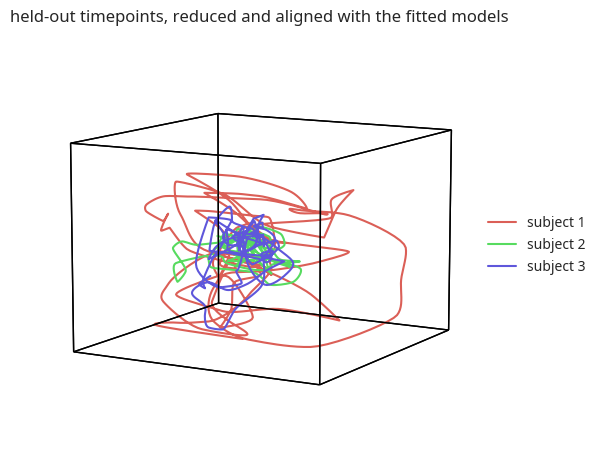

In [5]:
aligned, aligner = hyp.align(reduced, model='HyperAlign', return_model=True)
aligned_test = hyp.align(projected, model=aligner)
print(aligner, [np.asarray(a).shape for a in aligned], '->', [np.asarray(a).shape for a in aligned_test])
fig = hyp.plot(aligned_test, names=['subject 1', 'subject 2', 'subject 3'],
               title='held-out timepoints, reduced and aligned with the fitted models')

## `cluster`

`hyp.cluster` returns one label per row of the stacked input. The fitted clusterer assigns held-out rows to the training clusters through `model=`.

In [6]:
labels, kmeans = hyp.cluster(train, cluster='KMeans', n_clusters=4, return_model=True)
test_labels = hyp.cluster(test, model=kmeans)
print(kmeans, 'training labels:', np.bincount(labels), ' held-out labels:', np.bincount(test_labels))

Clusterer(model=<class 'sklearn.cluster._kmeans.KMeans'>,
          params={'n_clusters': 4}) training labels: [194 200 177  29]  held-out labels: [109  88 103]


## `predict`

`hyp.predict` returns the forecast (`t` rows) and, with `return_model=True`, the fitted forecaster. Passing a fitted forecaster back as `model=` reuses its learned parameters on new history rather than re-estimating them.

In [7]:
forecast, kalman = hyp.predict(train[0], model='Kalman', t=10, return_model=True)
reused = hyp.predict(test[0], model=kalman, t=10)
print(kalman, 'fitted:', kalman.is_fitted, ' forecast shapes:', forecast.shape, reused.shape)

Kalman() fitted: True  forecast shapes: (10, 100) (10, 100)


## `impute`

`hyp.impute` fills missing (`NaN`) entries; PPCA, the default, preserves every observed value exactly. Keyword arguments go to the imputer's constructor -- `d=10` fits ten latent components rather than one per feature. The fitted imputer re-applies through `model=` to new data with holes in it.

In [8]:
rng = np.random.default_rng(0)
holey = train[0].copy()
holey[rng.random(holey.shape) < 0.05] = np.nan
filled, imputer = hyp.impute(holey, model='PPCA', d=10, return_model=True)
holey_test = test[0].copy()
holey_test[rng.random(holey_test.shape) < 0.05] = np.nan
filled_test = hyp.impute(holey_test, model=imputer)
print(imputer, ' NaNs before/after:', int(np.isnan(holey).sum()), int(np.isnan(np.asarray(filled)).sum()),
      ' held-out:', int(np.isnan(holey_test).sum()), int(np.isnan(np.asarray(filled_test)).sum()))
print('observed values preserved:', bool(np.allclose(np.asarray(filled)[~np.isnan(holey)], holey[~np.isnan(holey)])))

PPCA(d=10)  NaNs before/after: 991 0  held-out: 508 0
observed values preserved: True


## The `plot` bundle

`hyp.plot(..., return_model=True)` returns a dict instead of the figure: `fig`, `xform_data` (the analysed data), `trace_data` and `trace_metadata` (the drawn trajectories; the metadata is `None` unless the input was hierarchical), `animation` (the raw handle, `None` for a static plot), `pipeline` (a fitted `hyp.Pipeline` covering whichever stages ran), `models` (the reduce/align/cluster/impute specs) and `predict` (`None` unless `predict=` was set). The pipeline's steps are the stages, in the library's canonical order.

keys: ['animation', 'fig', 'models', 'pipeline', 'predict', 'trace_data', 'trace_metadata', 'xform_data']
pipeline steps: ['manip', 'normalize', 'reduce', 'align']
models: {'reduce': {'model': 'PCA', 'params': {'n_components': 3}}, 'align': {'model': 'HyperAlign', 'params': {}}, 'cluster': None, 'impute': None}
trace_metadata: None


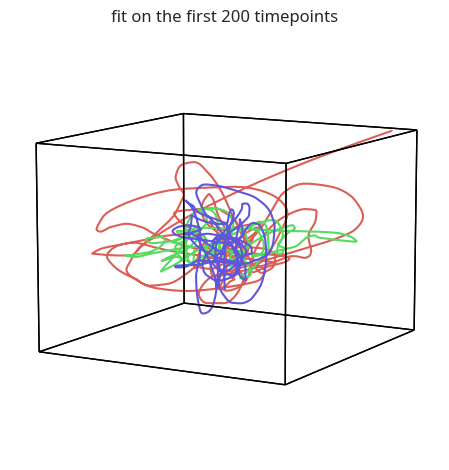

In [9]:
bundle = hyp.plot(train, manip='Smooth', normalize='across', reduce='PCA', align='HyperAlign',
                  return_model=True, title='fit on the first 200 timepoints')
print('keys:', sorted(bundle))
print('pipeline steps:', [name for name, _ in bundle['pipeline'].steps])
print('models:', bundle['models'])
print('trace_metadata:', bundle['trace_metadata'])

## Replaying a fitted pipeline with `pipeline=`

Handing the bundle's pipeline back as `pipeline=` applies the *same* fitted parameters -- the training smoother, scaler, reducer and aligner -- to new data, with no refitting. It is mutually exclusive with the stage kwargs (`manip=`, `normalize=`, `reduce=`, `align=`, `cluster=`), since those would fit new models. The same object is available from `hyp.analyze(..., return_model=True)`, whose second return value is the pipeline.

['manip', 'reduce', 'align'] [(100, 3), (100, 3), (100, 3)]


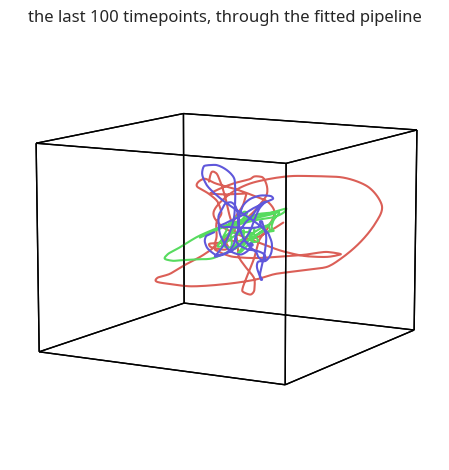

In [10]:
fig = hyp.plot(test, pipeline=bundle['pipeline'], title='the last 100 timepoints, through the fitted pipeline')
analysed, pipeline = hyp.analyze(train, manip='Smooth', reduce='PCA', ndims=3, align='HyperAlign', return_model=True)
print([name for name, _ in pipeline.steps], [np.asarray(a).shape for a in pipeline.transform(test)])

## `apply_model` and its modes

`hyp.apply_model(data, model, mode=)` runs any registered name, class, dict spec or scikit-learn-style instance on the stacked data. `mode='auto'` (the default) prefers `predict_proba`, then `fit_transform`/`transform`, then `fit_predict`; `'fit_transform'`, `'fit_predict'` and `'predict_proba'` ask for one explicitly, and a model that cannot honour it raises a `ValueError` naming what it does support. A list is a pipeline, and an explicit mode applies to its final stage; `return_model=True` then hands back a fitted `hyp.Pipeline`.

In [11]:
components = hyp.apply_model(train, 'PCA', mode='fit_transform', ndims=3)
clusters = hyp.apply_model(train, {'model': 'KMeans', 'kwargs': {'n_clusters': 4}}, mode='fit_predict')
memberships = hyp.apply_model(train, {'model': 'GaussianMixture', 'kwargs': {'n_components': 3}},
                              mode='predict_proba')
print('fit_transform:', [a.shape for a in components])
print('fit_predict:  ', [np.unique(a).tolist() for a in clusters])
print('predict_proba:', [a.shape for a in memberships], 'rows sum to', np.round(memberships[0].sum(axis=1)[:3], 3))
labels, pipe = hyp.apply_model(train, [{'model': 'PCA', 'kwargs': {'n_components': 3}},
                                       {'model': 'KMeans', 'kwargs': {'n_clusters': 4}}],
                               mode='fit_predict', return_model=True)
print('list spec:', pipe)
try:
    hyp.apply_model(train, 'PCA', mode='predict_proba')
except ValueError as error:
    print('a mode the model cannot honour:', str(error)[:100], '...')

fit_transform: [(200, 3), (200, 3), (200, 3)]
fit_predict:   [[0, 2, 3], [0, 1, 2, 3], [0, 1, 2, 3]]
predict_proba: [(200, 3), (200, 3), (200, 3)] rows sum to [1. 1. 1.]
list spec: Pipeline([pca=PCA(n_components=3), kmeans=KMeans(n_clusters=4)])
a mode the model cannot honour: PCA does not support mode='predict_proba' (it has no matching method); this model supports: fit_tran ...


## `supported_models()`

The names `apply_model` (and `reduce=`/`cluster=`) accept as strings. Manipulator, aligner, forecaster and imputer names (`'ZScore'`, `'HyperAlign'`, `'Kalman'`, `'PPCA'`, ...) belong to their own dispatchers, which operate on whole datasets rather than stacked rows.

In [12]:
hyp.supported_models()

['AffinityPropagation',
 'AgglomerativeClustering',
 'BayesianGaussianMixture',
 'Birch',
 'DBSCAN',
 'DictionaryLearning',
 'FactorAnalysis',
 'FastICA',
 'FeatureAgglomeration',
 'GaussianMixture',
 'HDBSCAN',
 'IncrementalPCA',
 'Isomap',
 'KMeans',
 'KernelPCA',
 'LatentDirichletAllocation',
 'LocallyLinearEmbedding',
 'MDS',
 'MeanShift',
 'MiniBatchDictionaryLearning',
 'MiniBatchKMeans',
 'MiniBatchSparsePCA',
 'NMF',
 'OPTICS',
 'PCA',
 'SparsePCA',
 'SpectralClustering',
 'SpectralEmbedding',
 'TSNE',
 'TruncatedSVD',
 'UMAP']

## `Pipeline` used directly

`hyp.Pipeline` mirrors scikit-learn's: `fit_transform` fits every step in order and `transform` re-applies the fitted steps. Each element is a spec (a name, class, instance or dict) or a `(name, spec)` tuple; bare specs are named after their class. Steps receive the running output as-is, so a raw scikit-learn step such as `PCA` sees a single array -- for a *list* of datasets, use the dispatcher kwargs or `apply_model`, whose pipelines stack for you (the `plot` and `analyze` pipelines above are of that kind).

Pipeline([smooth=Smooth(), pca=PCA(n_components=3)])  fitted: True
named steps: ['smooth', 'pca']  shapes: (200, 3) -> (100, 3)


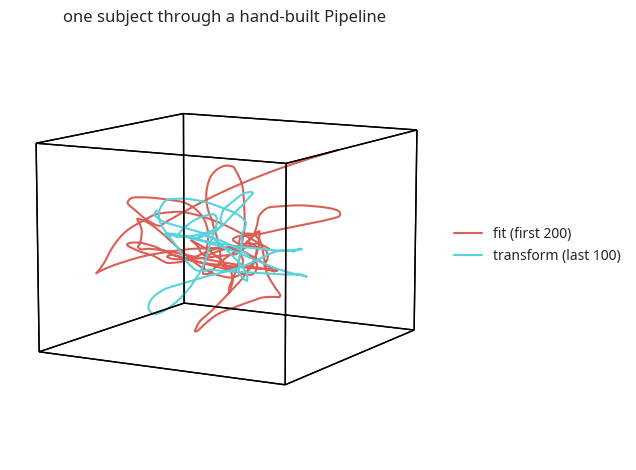

In [13]:
pipe = hyp.Pipeline(['Smooth', {'model': 'PCA', 'kwargs': {'n_components': 3}}])
fitted = pipe.fit_transform(train[0])
replayed = pipe.transform(test[0])
print(pipe, ' fitted:', pipe.is_fitted)
print('named steps:', list(pipe.named_steps), ' shapes:', np.asarray(fitted).shape, '->', np.asarray(replayed).shape)
fig = hyp.plot([fitted, replayed], names=['fit (first 200)', 'transform (last 100)'],
               title='one subject through a hand-built Pipeline')